# 01 — Análise exploratória

**Pergunta de negócio:** onde está o gasto hospitalar e como ele se comporta no tempo, entre regiões e entre
categorias de procedimento?

> ⚠️ Executado sobre a **base sintética** do projeto (ver `docs/data_sources.md`). Os números ilustram o
> método; não descrevem a realidade do SUS.

Unidade de análise: **competência × UF × subgrupo SIGTAP** (dados agregados, sem informação individual).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from hcb.config import load_settings
from hcb.analysis import indicators, statistics, outliers
from hcb.pipeline import FACT_FILE, run
from hcb.schema import REGION_ORDER

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.titlelocation": "left"})
REGION_COLORS = {"Norte": "#2a78d6", "Nordeste": "#eb6834", "Centro-Oeste": "#1baf7a",
                 "Sudeste": "#eda100", "Sul": "#e87ba4"}

settings = load_settings()
if not (settings.processed_dir / FACT_FILE).exists():
    run(settings)
fact = pd.read_csv(settings.processed_dir / FACT_FILE, dtype={"subgrupo_codigo": str, "grupo_codigo": str},
                   parse_dates=["data"])
fact["regiao"] = pd.Categorical(fact["regiao"], categories=REGION_ORDER, ordered=True)
print(f"{len(fact):,} linhas | {fact['competencia'].min()} a {fact['competencia'].max()}")


14,992 linhas | 2022-01 a 2024-12


## 1. Estrutura e completude

In [2]:
display(fact.head())
print("Células por região:"); display(fact.groupby("regiao", observed=True).size().rename("celulas").to_frame())
print("Nulos por coluna:"); display(fact.isna().sum()[lambda s: s > 0].rename("nulos").to_frame())

,competencia,data,ano,trimestre,uf_sigla,uf_nome,regiao,populacao,grupo_codigo,grupo_nome,subgrupo_codigo,subgrupo_nome,complexidade_referencia,qtd_internacoes,valor_total,dias_permanencia,custo_por_internacao,custo_por_dia,permanencia_media
0,2022-01,2022-01-01,2022,2022Q1,AC,Acre,Norte,830018,03,Procedimentos clínicos,0303,Tratamentos clínicos (outras especialidades),Média,975,"1,004,616.21","5,312.00","1,030.38",189.12,5.45
1,2022-01,2022-01-01,2022,2022Q1,AC,Acre,Norte,830018,03,Procedimentos clínicos,0304,Tratamento em oncologia,Alta,147,"321,343.30",762.00,"2,186.01",421.71,5.18
2,2022-01,2022-01-01,2022,2022Q1,AC,Acre,Norte,830018,03,Procedimentos clínicos,0305,Tratamento em nefrologia,Média,35,"39,005.49",203.00,"1,114.44",192.15,5.80
3,2022-01,2022-01-01,2022,2022Q1,AC,Acre,Norte,830018,03,Procedimentos clínicos,0308,"Tratamento de lesões, envenenamentos e outros,...",Média,95,"73,290.67",281.00,771.48,260.82,2.96
4,2022-01,2022-01-01,2022,2022Q1,AC,Acre,Norte,830018,03,Procedimentos clínicos,0310,Parto e nascimento,Média,446,"299,698.01",992.00,671.97,302.11,2.22


Células por região:


,celulas
regiao,
Norte,3775
Nordeste,4962
Centro-Oeste,2229
Sudeste,2301
Sul,1725


Nulos por coluna:


,nulos


## 2. KPIs gerais
O custo médio é **ponderado** (Σ valor ÷ Σ internações). A média simples das células daria o mesmo peso a
uma UF pequena e a São Paulo — por isso não é usada.

In [3]:
k = indicators.kpis(fact)
pd.Series(k).to_frame("valor")

,valor
linhas,14992
periodo_inicio,2022-01
periodo_fim,2024-12
meses,36
valor_total,"65,907,927,963.75"
internacoes,35535036
custo_medio_por_internacao,"1,854.73"
custo_mediano_celula,"1,430.53"
custo_mediano_ponderado,"1,246.10"
custo_por_dia,451.69


## 3. Como os custos evoluem ao longo do tempo?

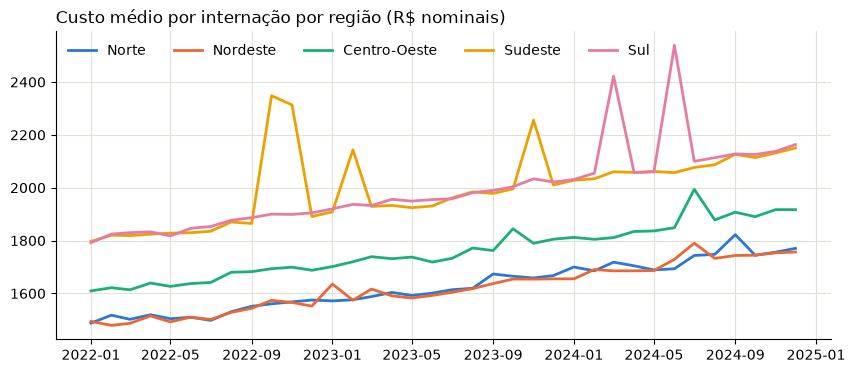

,data,custo_medio_por_internacao,media_movel_3m,variacao_12m
24,2024-01-01,"1,891.72","1,917.96",0.05
25,2024-02-01,"1,905.38","1,892.28",0.01
26,2024-03-01,"1,980.63","1,925.91",0.09
27,2024-04-01,"1,918.52","1,934.84",0.06
28,2024-05-01,"1,920.03","1,939.73",0.07
29,2024-06-01,"2,011.20","1,949.92",0.11
30,2024-07-01,"1,976.13","1,969.12",0.08
31,2024-08-01,"1,958.88","1,982.07",0.06
32,2024-09-01,"1,988.51","1,974.51",0.07
33,2024-10-01,"1,976.54","1,974.64",0.06


In [4]:
m = indicators.monthly(fact, "regiao")
fig, ax = plt.subplots()
for r in REGION_ORDER:
    p = m[m["regiao"] == r]
    ax.plot(p["data"], p["custo_medio_por_internacao"], color=REGION_COLORS[r], lw=2, label=r)
ax.set_title("Custo médio por internação por região (R$ nominais)")
ax.legend(ncol=5, loc="upper left", frameon=False)
plt.show()

total = indicators.monthly(fact)
total[["data", "custo_medio_por_internacao", "media_movel_3m", "variacao_12m"]].tail(12)

**Leitura:** tendência de alta em todas as regiões (a base sintética embute ~6% a.a. de reajuste
nominal). Os picos isolados em algumas regiões coincidem com as células atípicas analisadas no notebook 03 —
uma única célula de grande volume pode deslocar a média mensal de uma região inteira.

## 4. Distribuição dos custos

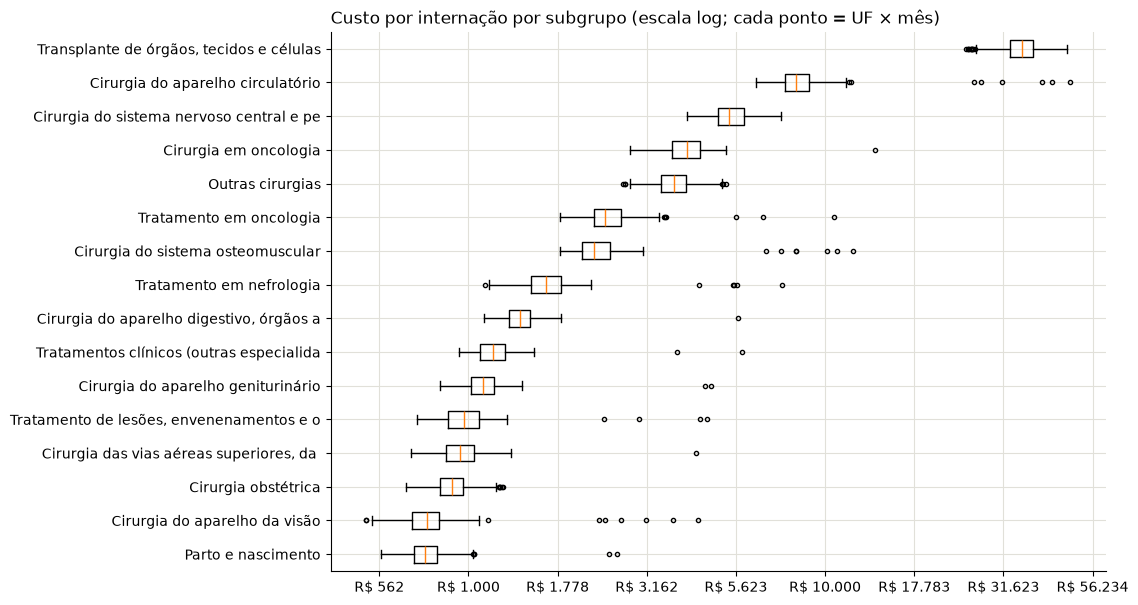

In [5]:
order = fact.groupby("subgrupo_nome")["custo_por_internacao"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot([np.log10(fact.loc[fact["subgrupo_nome"] == n, "custo_por_internacao"]) for n in order],
           orientation="horizontal", tick_labels=[n[:40] for n in order], flierprops={"markersize": 3})
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {10**v:,.0f}".replace(",", ".")))
ax.set_title("Custo por internação por subgrupo (escala log; cada ponto = UF × mês)")
plt.show()

A distribuição é **assimétrica à direita** e varia em ordens de grandeza entre subgrupos (parto
≈ R$ 800 vs. transplante ≈ R$ 35 mil). Por isso: (i) comparações são feitas *dentro* do subgrupo, (ii) usa-se
escala log e (iii) estatísticas robustas (mediana, IQR, MAD).

## 5. Quais grupos concentram maior volume financeiro?

In [6]:
table, summary = indicators.concentration(fact, "subgrupo_nome", 0.8)
print(summary)
table.head(10)

{'dimensao': 'subgrupo_nome', 'itens': 16, 'itens_para_participacao_alvo': 8, 'participacao_alvo': 0.8, 'hhi': 1133.1, 'top1_participacao': 0.21453756535506605}


,subgrupo_nome,valor_total,participacao,participacao_acumulada,nucleo_pareto
0,Tratamentos clínicos (outras especialidades),"14,139,726,402.94",0.21,0.21,True
1,Cirurgia do aparelho circulatório,"10,497,856,356.25",0.16,0.37,True
2,Cirurgia do sistema osteomuscular,"8,092,514,595.95",0.12,0.50,True
3,"Cirurgia do aparelho digestivo, órgãos anexos ...","5,943,074,906.21",0.09,0.59,True
4,Parto e nascimento,"3,928,150,309.40",0.06,0.65,True
5,Tratamento em oncologia,"3,732,609,443.23",0.06,0.70,True
6,Cirurgia do sistema nervoso central e periférico,"3,248,384,192.78",0.05,0.75,True
7,Cirurgia em oncologia,"3,183,370,410.18",0.05,0.80,True
8,Cirurgia obstétrica,"3,167,731,519.56",0.05,0.85,False
9,Outras cirurgias,"2,863,262,929.35",0.04,0.89,False


## 6. Comparação entre regiões — bruta vs. ajustada ao mix

In [7]:
reg = indicators.summarize(fact, "regiao").merge(indicators.mix_adjusted_index(fact, "regiao"), on="regiao")
reg = reg.merge(indicators.utilization_rate(fact, "regiao"), on="regiao")
reg[["regiao", "custo_medio_por_internacao", "indice_custo_ajustado", "internacoes_por_10mil_hab_mes",
     "participacao_valor"]]

,regiao,custo_medio_por_internacao,indice_custo_ajustado,internacoes_por_10mil_hab_mes,participacao_valor
0,Sudeste,"1,999.24",1.07,48.84,0.45
1,Nordeste,"1,619.52",0.88,46.33,0.22
2,Sul,"1,995.76",1.07,56.18,0.18
3,Centro-Oeste,"1,759.38",0.96,48.80,0.08
4,Norte,"1,625.73",0.91,41.40,0.06


O **índice ajustado ao mix** compara cada região com o que ela custaria se cada internação tivesse
o custo nacional do seu subgrupo no mesmo mês. Ele separa "faz procedimentos mais caros" de "paga mais pelo
mesmo tipo de procedimento". Ainda assim, **não controla gravidade dentro do subgrupo**, portanto diferenças
não devem ser lidas como ineficiência sem investigação adicional.